### Testing custom TTF transformations
This notebook can be used to visualize the different (custom) versions of the TTF transformation.

In [1]:
from typing import Union
import numpy as np
import openturns as ot
import torch

import matplotlib.pyplot as plt

# To avoid meshgrid warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='torch')

from tailnflows.models.extreme_transformations import ModifiedTailAffineMarginalTransform
from tailnflows.models.extreme_transformations_ORIG import TailAffineMarginalTransform
from tailnflows.models.tail_estimation import estimate_df
from tailnflows.targets.synth_targets import NealsFunnel, Student, GaussianCopula

### Plot the 1d Transformation

In [2]:
def plot_transform(transforms: list[Union[TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform]], x_low: float = -5.0, x_high: float = 5.0, num_points: int = 1000):
    """
    Plot the forward and inverse transformations along with their lads.
    
    Args:
        transform: The transformation to plot.
        x_low (float): The lower bound of the domain on which to plot.
        x_high (float): The upper bound of the domain on which to plot.
        num_points (int): The number of points to plot.
    """
    x = np.linspace(x_low, x_high, num_points)

    fig, axs = plt.subplots(2, 2, figsize=(12, 6))

    for i, transform in enumerate(transforms):
        x_tensor = torch.from_numpy(x).to('cpu').float().unsqueeze(-1)
        y_fwd, lad_fwd = transform.forward(x_tensor)
        y_fwd = y_fwd.detach().numpy()
        lad_fwd = lad_fwd.detach().numpy()
        y_back, lad_back = transform.inverse(x_tensor)
        y_back = y_back.detach().numpy()
        lad_back = lad_back.detach().numpy()

        if i == 0:
            axs[0, 0].plot(x, y_fwd, 'b-', label='Transform 1')
            axs[0, 1].plot(x, lad_fwd, 'b-', label='Transform 1')
            axs[1, 0].plot(x, y_back, 'b-', label='Transform 1')
            axs[1, 1].plot(x, lad_back, 'b-', label='Transform 1')

        else:
            axs[0, 0].plot(x, y_fwd, 'r:', label=f'Transform {i+1}')
            axs[0, 1].plot(x, lad_fwd, 'r:', label=f'Transform {i+1}')
            axs[1, 0].plot(x, y_back, 'r:', label=f'Transform {i+1}')
            axs[1, 1].plot(x, lad_back, 'r:', label=f'Transform {i+1}')

    axs[0, 0].set_title('Forward Transformation')
    axs[0, 0].grid()
    axs[0, 0].set_xlim(x_low, x_high)
    axs[0, 1].set_title('Forward Transformation Lad')
    axs[0, 1].grid()
    axs[0, 1].set_xlim(x_low, x_high)
    axs[1, 0].set_title('Inverse Transformation')
    axs[1, 0].grid()
    axs[1, 0].set_xlim(x_low, x_high)
    axs[1, 1].set_title('Inverse Transformation Lad')
    axs[1, 1].grid()
    axs[1, 1].set_xlim(x_low, x_high)

    axs[0, 0].legend()
    axs[0, 1].legend()
    axs[1, 0].legend()
    axs[1, 1].legend()

    fig.tight_layout()
    fig.show()

Standard TTF: No breaking points needed, thus fixed.
Fixed breakpoint params.


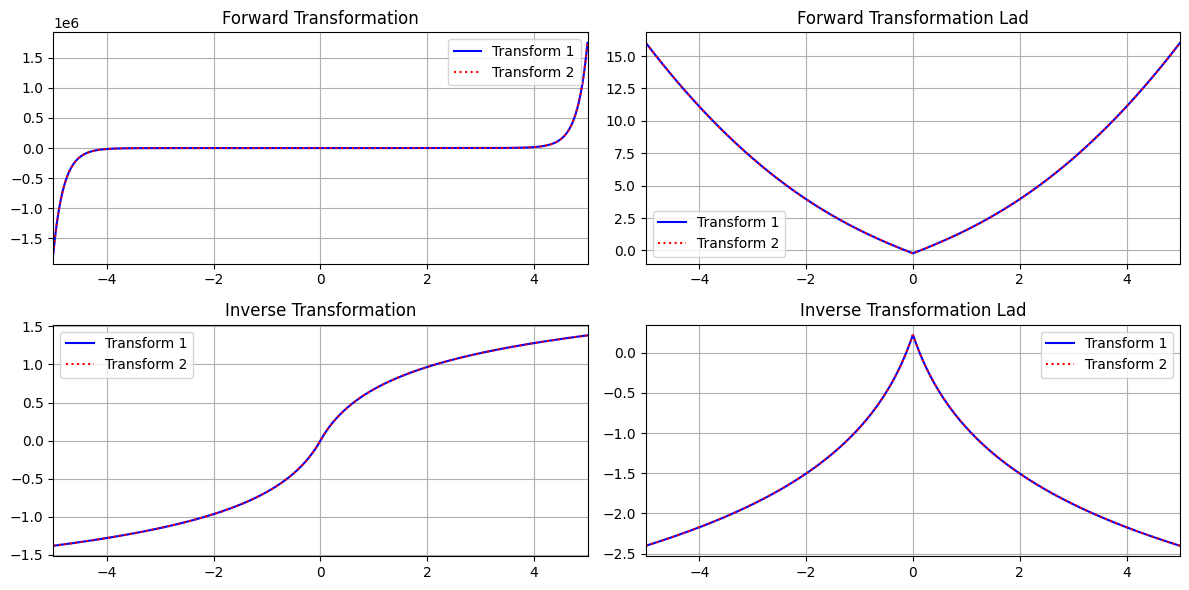

In [9]:
lam_pos = 1.0
lam_neg = 1.0
shift = 0.0
scale = 1.0
hd_only = False
mod = "std"
a_pos = 0.0
a_neg = -0.0

x_low = -5.0
x_high = 5.0

trafo_ttf = ModifiedTailAffineMarginalTransform(
    features=1,
    pos_tail_init=torch.tensor([lam_pos]),
    neg_tail_init=torch.tensor([lam_neg]),
    shift_init=torch.tensor([shift]),
    scale_init=torch.tensor([scale]),
    hd_only=hd_only,
    mod=mod,
    a_pos_init=torch.tensor([a_pos]) if a_pos is not None else None,
    a_neg_init=torch.tensor([a_neg]) if a_neg is not None else None,
    fix_params=False,
)

trafo_ttf_orig = TailAffineMarginalTransform(
    features=1,
    pos_tail_init=torch.tensor([lam_pos]),
    neg_tail_init=torch.tensor([lam_neg]),
    shift_init=torch.tensor([shift]),
    scale_init=torch.tensor([scale]),
)

transforms = [trafo_ttf, trafo_ttf_orig]

plot_transform(transforms, x_low, x_high)

### Transform 2d Data
Here we plot inverse (heavy -> light) TTF transformed target distributions (Neal's Funnel, Student-t, Gaussian Copula).

data_neal.shape:  torch.Size([32000, 2])
data_student.shape:  torch.Size([32000, 2])
data_gauss.shape:  torch.Size([32000, 2])
z.shape:  torch.Size([160000, 2])
log_p_neal.shape:  torch.Size([160000])
log_p_student.shape:  torch.Size([160000])
log_p_gauss.shape:  torch.Size([160000])
likelihood_neal.shape:  (400, 400)
likelihood_student.shape:  (400, 400)
likelihood_gauss.shape:  (400, 400)


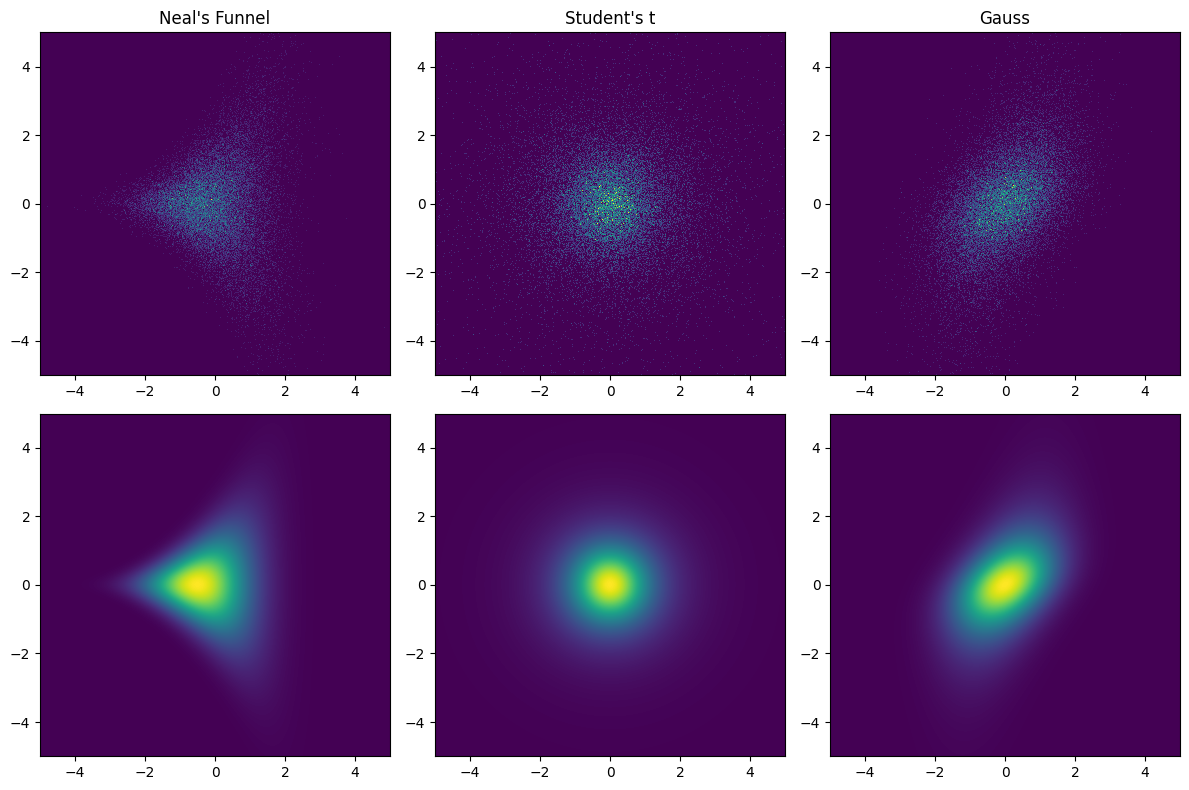

In [ ]:
# Set number of samples
num_samples = 32000

# Generate target distributions
target_neal = NealsFunnel() # mixed-tailed

df = 2.5 # True df for Student-t marginals
target_student = Student(dim=2, df=df) # heavy-tailed

target_gauss = GaussianCopula(num_light=1, num_heavy=1, corr_matrix=ot.CorrelationMatrix(2, (1.0, 0.5, 0.5, 1.0))) # mixed-tailed

# Sample from target distributions
data_neal = target_neal.sample(num_samples).to('cpu').float()
data_student = target_student.sample(num_samples).to('cpu').float()
data_gauss = target_gauss.sample(num_samples).to('cpu').float()
print("data_neal.shape: ", data_neal.shape)
print("data_student.shape: ", data_student.shape)
print("data_gauss.shape: ", data_gauss.shape)

# parameters for 2d grid
x_low, x_high = -5, 5
y_low, y_high = -5, 5
bins = 400
grid_size = 400

range_hist2d = ((x_low,x_high), (y_low,y_high))
extent_imshow = (x_low, x_high, y_low, y_high)

# Prepare grid points
z = torch.meshgrid(torch.linspace(x_low, x_high, grid_size), torch.linspace(y_low, y_high, grid_size), indexing='xy')
z = torch.stack([z[0].flatten(), z[1].flatten()], dim=1).to('cpu')
print("z.shape: ", z.shape)

# Compute likelihoods
log_p_neal = target_neal.log_prob(z)
log_p_student = target_student.log_prob(z)
log_p_gauss = target_gauss.log_prob(z)
print("log_p_neal.shape: ", log_p_neal.shape)
print("log_p_student.shape: ", log_p_student.shape)
print("log_p_gauss.shape: ", log_p_gauss.shape)
likelihood_neal = torch.exp(log_p_neal).reshape(grid_size, grid_size).detach().cpu().numpy()
likelihood_student = torch.exp(log_p_student).reshape(grid_size, grid_size).detach().cpu().numpy()
likelihood_gauss = torch.exp(log_p_gauss).reshape(grid_size, grid_size).detach().cpu().numpy()
print("likelihood_neal.shape: ", likelihood_neal.shape)
print("likelihood_student.shape: ", likelihood_student.shape)
print("likelihood_gauss.shape: ", likelihood_gauss.shape)

# Plot samples and likelihoods
fig, axs = plt.subplots(2, 3, figsize=(12,8))
axs[0, 0].hist2d(data_neal[:, 0], data_neal[:, 1], bins=bins, range=range_hist2d, density=True)
axs[0, 0].set_title("Neal's Funnel")
axs[0, 1].hist2d(data_student[:, 0], data_student[:, 1], bins=bins, range=range_hist2d, density=True)
axs[0, 1].set_title("Student's t")
axs[0, 2].hist2d(data_gauss[:, 0], data_gauss[:, 1], bins=bins, range=range_hist2d, density=True)
axs[0, 2].set_title("Gauss")
axs[1, 0].imshow(likelihood_neal, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
axs[1, 1].imshow(likelihood_student, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
axs[1, 2].imshow(likelihood_gauss, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')

plt.tight_layout()
plt.show()

data_neal_trnf.shape:  (32000, 2)
data_student_trnf.shape:  (32000, 2)
data_gauss_trnf.shape:  (32000, 2)
log_p_neal_trnf.shape:  torch.Size([160000])
log_p_student_trnf.shape:  torch.Size([160000])
log_p_gauss_trnf.shape:  torch.Size([160000])
likelihood_neal_trnf.shape:  (400, 400)
likelihood_student_trnf.shape:  (400, 400)
likelihood_gauss_trnf.shape:  (400, 400)


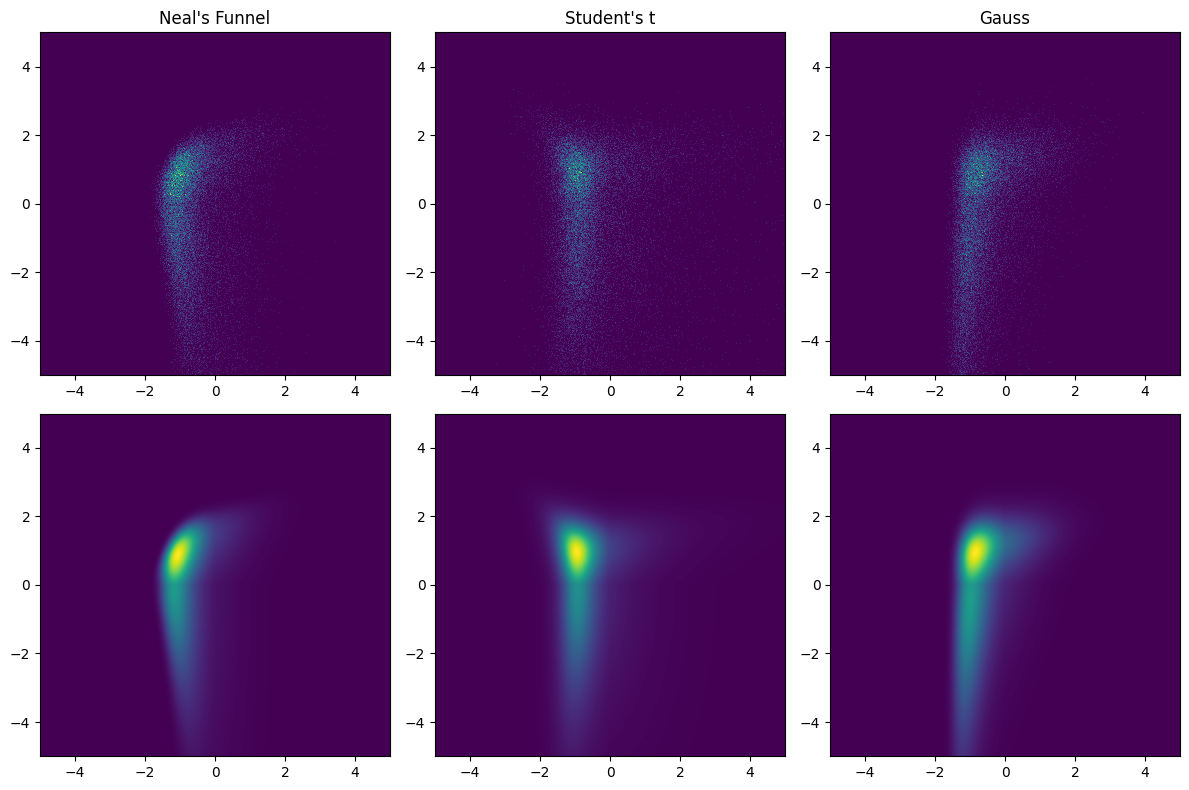

In [ ]:
# Parameters for TTF transformation
features = 2
lam_1_pos = 0.0
lam_1_neg = 1/df
lam_2_pos = 1/df
lam_2_neg = 0.0
shift_1 = 1.0
shift_2 = 0.0
scale_1 = 1.0
scale_2 = 0.5
mod = 'std'
a_1_pos = 1.0
a_1_neg = -1.0
a_2_pos = 1.0
a_2_neg = -1.0
hd_only = True
fix_params = False

trnf = ModifiedTailAffineMarginalTransform(
    features = features,
    pos_tail_init = torch.tensor([lam_1_pos, lam_2_pos]),
    neg_tail_init = torch.tensor([lam_1_neg, lam_2_neg]),
    shift_init = torch.tensor([shift_1, shift_2]),
    scale_init = torch.tensor([scale_1, scale_2]),
    hd_only = hd_only,
    mod = mod,
    a_pos_init = torch.tensor([a_1_pos, a_2_pos]) if a_1_pos is not None and a_2_pos is not None else None,
    a_neg_init = torch.tensor([a_1_neg, a_2_neg]) if a_1_neg is not None and a_2_neg is not None else None,
    fix_params = fix_params,
)

# Inversely transform data samples
data_neal_trnf = trnf.inverse(data_neal)[0].detach().numpy()
data_student_trnf = trnf.inverse(data_student)[0].detach().numpy()
data_gauss_trnf = trnf.inverse(data_gauss)[0].detach().numpy()
print("data_neal_trnf.shape: ", data_neal_trnf.shape)
print("data_student_trnf.shape: ", data_student_trnf.shape)
print("data_gauss_trnf.shape: ", data_gauss_trnf.shape)

# Compute likelihood of inversely transformed distributions
x, lad = trnf.forward(z)
log_p_neal_trnf = target_neal.log_prob(x) + lad
log_p_student_trnf = target_student.log_prob(x) + lad
log_p_gauss_trnf = target_gauss.log_prob(x) + lad
print("log_p_neal_trnf.shape: ", log_p_neal_trnf.shape)
print("log_p_student_trnf.shape: ", log_p_student_trnf.shape)
print("log_p_gauss_trnf.shape: ", log_p_gauss_trnf.shape)
likelihood_neal_trnf = torch.exp(log_p_neal_trnf).reshape(grid_size, grid_size).detach().cpu().numpy()
likelihood_student_trnf = torch.exp(log_p_student_trnf).reshape(grid_size, grid_size).detach().cpu().numpy()
likelihood_gauss_trnf = torch.exp(log_p_gauss_trnf).reshape(grid_size, grid_size).detach().cpu().numpy()
print("likelihood_neal_trnf.shape: ", likelihood_neal_trnf.shape)
print("likelihood_student_trnf.shape: ", likelihood_student_trnf.shape)
print("likelihood_gauss_trnf.shape: ", likelihood_gauss_trnf.shape)

# Plot inversely transformed likelihoods
fig, axs = plt.subplots(2, 3, figsize=(12,8))
axs[0, 0].hist2d(data_neal_trnf[:, 0], data_neal_trnf[:, 1], bins=bins, range=range_hist2d, density=True)
axs[0, 0].set_title("Neal's Funnel")
axs[0, 1].hist2d(data_student_trnf[:, 0], data_student_trnf[:, 1], bins=bins, range=range_hist2d, density=True)
axs[0, 1].set_title("Student's t")
axs[0, 2].hist2d(data_gauss_trnf[:, 0], data_gauss_trnf[:, 1], bins=bins, range=range_hist2d, density=True)
axs[0, 2].set_title("Gauss")
axs[1, 0].imshow(likelihood_neal_trnf, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
axs[1, 1].imshow(likelihood_student_trnf, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')
axs[1, 2].imshow(likelihood_gauss_trnf, extent=extent_imshow, aspect='auto', origin='lower', cmap='viridis')

plt.tight_layout()
plt.show()